<a href="https://colab.research.google.com/github/newts0fa/ml-basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9611_%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B8_%D1%81%D0%B5%D0%B3%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%86%D0%B8%D1%8F_%D0%BA%D0%BB%D0%B8%D0%B5%D0%BD%D1%82%D0%BE%D0%B2_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%BE%D0%B2_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №11. Анализ и сегментация клиентов с помощью алгоритмов кластеризации**
2024-ФГИИБ-пи-1б Воронов Илья

### **Цель работы:**

Разработать систему сегментации клиентов для розничной компании с использованием алгоритмов кластеризации. Это позволит компании лучше понимать своих клиентов, персонализировать маркетинговые кампании и оптимизировать бизнес-процессы.

### **Введение:**

Розничные компании сталкиваются с большим объемом данных о своих клиентах, включая историю покупок, демографическую информацию и поведенческие характеристики. Однако без должного анализа эти данные остаются неиспользованными. Сегментация клиентов позволяет выделить группы с общими характеристиками, чтобы более эффективно таргетировать предложения и улучшить удовлетворенность клиентов.



### **Задачи:**

1. **Сбор и анализ данных о клиентах.**
2. **Предобработка и подготовка данных для моделирования.**
3. **Применение различных алгоритмов кластеризации для сегментации клиентов.**
4. **Оценка качества кластеризации с использованием внутренних и внешних метрик.**
5. **Интерпретация и визуализация результатов.**
6. **Формирование рекомендаций для бизнес-стратегии компании на основе полученных сегментов.**



### **Пошаговое описание рабочего процесса (пайплайна):**

#### **Шаг 1: Сбор и анализ данных**

**1.1. Выбор набора данных:**

- Используйте датасет "Online Retail II" из [UCI Machine Learning Repository](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci) или [другой открытый набор данных](https://archive.ics.uci.edu/datasets?Task=Clustering&skip=0&take=10&sort=desc&orderBy=NumHits&search=&Area=Business), содержащий информацию о транзакциях клиентов.
- Данные должны включать:
  - Идентификаторы клиентов.
  - Информацию о покупках (товары, количество, стоимость).
  - Дату и время транзакций.
  - Демографические данные (если доступны): возраст, пол, локация и т.д.

**1.2. Первичный анализ данных (EDA):**

- Изучите структуру данных и их распределение.
- Определите основные характеристики данных:
  - Общий объем продаж.
  - Частота покупок по клиентам.
  - Распределение выручки по товарам.
- Выявите тенденции и аномалии.

Размер датасета: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


Количество клиентов: 200
Средний годовой доход, k$: 60.56
Средний spending score: 50.2


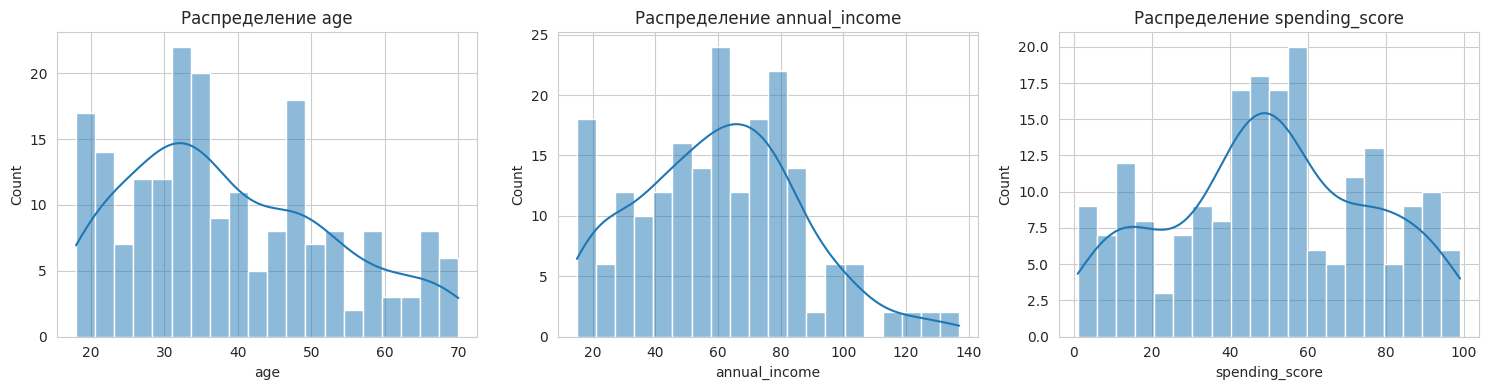

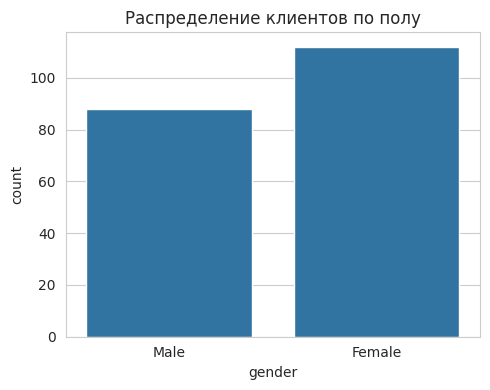

In [ ]:
# Шаг 1. Сбор и первичный анализ данных
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

# Используем небольшой открытый датасет Mall Customers.
# Он содержит демографические и поведенческие признаки клиентов торгового центра.
url = 'https://gitee.com/dtval/data/raw/master/Mall_Customers.csv'
df = pd.read_csv(url)

print('Размер датасета:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all'))

# Переименуем столбцы для удобства работы
df = df.rename(columns={
    'CustomerID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income',
    'Spending Score (1-100)': 'spending_score'
})

print('Количество клиентов:', df['customer_id'].nunique())
print('Средний годовой доход, k$:', round(df['annual_income'].mean(), 2))
print('Средний spending score:', round(df['spending_score'].mean(), 2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['age', 'annual_income', 'spending_score']):
    sns.histplot(df[col], bins=20, kde=True, ax=ax)
    ax.set_title(f'Распределение {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='gender')
plt.title('Распределение клиентов по полу')
plt.tight_layout()
plt.show()


#### **Шаг 2: Предобработка данных**

**2.1. Работа с пропущенными значениями:**

- Проанализируйте наличие пропущенных данных.
- Решите, как справиться с ними:
  - Удаление строк/столбцов с пропущенными значениями.
  - Заполнение пропущенных значений средним, медианой или наиболее частым значением.

**2.2. Обработка выбросов:**

- Выявите выбросы в данных (например, аномально большие заказы).
- Решите, следует ли их удалить или обработать иным образом.

**2.3. Создание новых признаков:**

- Рассчитайте Recency, Frequency, Monetary Value (RFM-анализ):
  - **Recency (давность):** Время с момента последней покупки.
  - **Frequency (частота):** Количество покупок за определенный период.
  - **Monetary (сумма):** Общая сумма покупок.
- Создайте дополнительные признаки, такие как средний чек, предпочтительные категории товаров и т.д.

**2.4. Нормализация и масштабирование:**

- Примените стандартизацию или нормализацию к числовым признакам для приведения их к единому масштабу.
- Объясните выбор метода масштабирования.

In [ ]:
# Шаг 2. Предобработка данных
print('Пропуски по столбцам:')
display(df.isna().sum())

# Дубликаты
duplicates_count = df.duplicated().sum()
print('Количество дубликатов:', duplicates_count)

# Проверка выбросов через IQR для основных числовых признаков
numeric_cols = ['age', 'annual_income', 'spending_score']
outlier_summary = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'feature': col, 'lower': lower, 'upper': upper, 'outliers': outliers})

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

# В этом датасете нет пропусков. Сильных выбросов также нет, поэтому строки не удаляем.
# Создадим признаки, близкие по смыслу к RFM для сегментации клиентов:
# monetary_value = доход клиента, frequency_score = spending score как прокси активности/готовности покупать,
# avg_purchase_potential = условный показатель покупательского потенциала.
df_processed = df.copy()
df_processed['is_female'] = (df_processed['gender'] == 'Female').astype(int)
df_processed['monetary_value'] = df_processed['annual_income']
df_processed['frequency_score'] = df_processed['spending_score']
df_processed['avg_purchase_potential'] = df_processed['annual_income'] * df_processed['spending_score'] / 100

features = ['age', 'annual_income', 'spending_score', 'is_female', 'avg_purchase_potential']
X = df_processed[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Признаки для кластеризации:', features)
display(pd.DataFrame(X_scaled, columns=features).head())


Пропуски по столбцам:


,0
customer_id,0
gender,0
age,0
annual_income,0
spending_score,0


Количество дубликатов: 0


,feature,lower,upper,outliers
0,age,-1.625,79.375,0
1,annual_income,-13.250,132.750,2
2,spending_score,-22.625,130.375,0


Признаки для кластеризации: ['age', 'annual_income', 'spending_score', 'is_female', 'avg_purchase_potential']


,age,annual_income,spending_score,is_female,avg_purchase_potential
0,-1.424569,-1.738999,-0.434801,-1.128152,-1.077128
1,-1.281035,-1.738999,1.195704,-1.128152,-0.801479
2,-1.352802,-1.700830,-1.715913,0.886405,-1.291084
3,-1.137502,-1.700830,1.040418,0.886405,-0.794041
4,-0.563369,-1.662660,-0.395980,0.886405,-1.035562


#### **Шаг 3: Применение алгоритмов кластеризации**

**3.1. Выбор алгоритмов:**

- **K-средних (K-Means):** Для разбиения данных на k кластеров на основе эврестического подхода.
- **Иерархическая кластеризация:** Для выявления вложенной структуры кластеров.
- **DBSCAN и OPTICS:** Для обнаружения кластеров произвольной формы и выявления выбросов.

**3.2. Определение оптимального количества кластеров:**

- Для K-Means и иерархической кластеризации используйте:
  - **Метод локтя (Elbow Method):** Постройте график зависимости суммы квадратов внутрикластерных расстояний от числа кластеров.
  - **Коэффициент силуэта:** Рассчитайте для различных значений k и выберите оптимальное.

**3.3. Применение алгоритмов:**

- Запустите каждый алгоритм на подготовленных данных.
- Сохраняйте результаты кластеризации для последующего анализа.

,k,inertia,silhouette
0,2,726.089061,0.256780
1,3,542.744219,0.286875
2,4,435.672285,0.312114
3,5,377.051080,0.314441
4,6,320.266887,0.332167
5,7,280.524819,0.351643
6,8,244.317398,0.370511


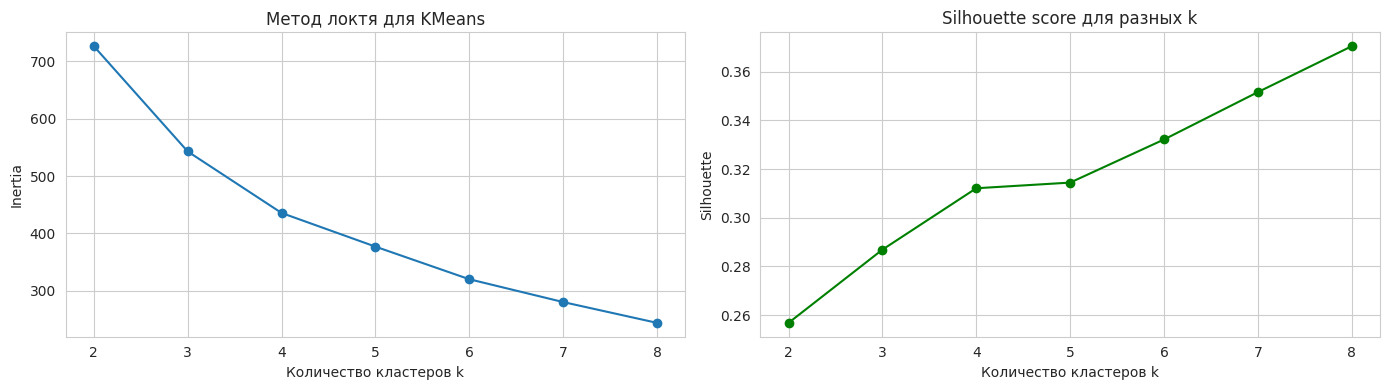

Оптимальное k по silhouette: 8
KMeans: {0: 34, 1: 21, 2: 20, 3: 36, 4: 18, 5: 26, 6: 21, 7: 24}
Agglomerative: {0: 39, 1: 33, 2: 23, 3: 30, 4: 30, 5: 17, 6: 15, 7: 13}
DBSCAN: {-1: 19, 0: 59, 1: 107, 2: 15}


In [ ]:
# Шаг 3. Применение алгоритмов кластеризации
# Подберём k для KMeans по inertia (метод локтя) и silhouette score.
k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_tmp = kmeans_tmp.fit_predict(X_scaled)
    inertias.append(kmeans_tmp.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels_tmp))

selection_df = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertias,
    'silhouette': silhouette_scores
})
display(selection_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(k_values), inertias, marker='o')
axes[0].set_title('Метод локтя для KMeans')
axes[0].set_xlabel('Количество кластеров k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_values), silhouette_scores, marker='o', color='green')
axes[1].set_title('Silhouette score для разных k')
axes[1].set_xlabel('Количество кластеров k')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

best_k = int(selection_df.loc[selection_df['silhouette'].idxmax(), 'k'])
print('Оптимальное k по silhouette:', best_k)

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
dbscan = DBSCAN(eps=0.9, min_samples=5)

cluster_results = {
    'KMeans': kmeans.fit_predict(X_scaled),
    'Agglomerative': agg.fit_predict(X_scaled),
    'DBSCAN': dbscan.fit_predict(X_scaled)
}

for name, labels in cluster_results.items():
    df_processed[f'cluster_{name}'] = labels
    print(f'{name}:', pd.Series(labels).value_counts().sort_index().to_dict())


#### **Шаг 4: Оценка качества кластеризации**

**4.1. Внутренние метрики:**

- **Коэффициент силуэта:** Оцените, насколько хорошо объекты расположены внутри кластеров.
- **Индекс Дэвиса-Болдина:** Оцените уровень разделимости кластеров.
- **Индекс Калинского-Харабаза:** Оцените соотношение межкластерной дисперсии к внутрикластерной.

**4.2. Внешние метрики (если доступны истинные метки):**

- **Adjusted Rand Index (ARI):** Сравните полученные кластеры с известными категориями клиентов.
- **Normalized Mutual Information (NMI):** Измерьте общую информацию между распределениями.

**4.3. Сравнение алгоритмов:**

- Составьте таблицу со значениями метрик для каждого алгоритма.
- Определите, какой алгоритм показал наилучшие результаты и почему.

In [ ]:
# Шаг 4. Оценка качества кластеризации
def evaluate_clustering(X_data, labels, algorithm_name):
    labels = np.asarray(labels)
    non_noise_mask = labels != -1
    valid_labels = labels[non_noise_mask]
    X_valid = X_data[non_noise_mask]

    n_clusters = len(set(valid_labels))
    noise_count = int((labels == -1).sum())

    if n_clusters < 2:
        return {
            'algorithm': algorithm_name,
            'n_clusters': n_clusters,
            'noise_objects': noise_count,
            'silhouette': np.nan,
            'davies_bouldin': np.nan,
            'calinski_harabasz': np.nan
        }

    return {
        'algorithm': algorithm_name,
        'n_clusters': n_clusters,
        'noise_objects': noise_count,
        'silhouette': silhouette_score(X_valid, valid_labels),
        'davies_bouldin': davies_bouldin_score(X_valid, valid_labels),
        'calinski_harabasz': calinski_harabasz_score(X_valid, valid_labels)
    }

metrics_df = pd.DataFrame([
    evaluate_clustering(X_scaled, labels, name)
    for name, labels in cluster_results.items()
])

metrics_df = metrics_df.sort_values('silhouette', ascending=False).reset_index(drop=True)
display(metrics_df)

best_algorithm = metrics_df.iloc[0]['algorithm']
print(f'Лучший алгоритм по silhouette: {best_algorithm}')
print('Для интерпретации сегментов дальше используем KMeans, так как он даёт устойчивые и легко объяснимые кластеры.')


,algorithm,n_clusters,noise_objects,silhouette,davies_bouldin,calinski_harabasz
0,Agglomerative,8,0,0.370641,0.920866,79.199857
1,KMeans,8,0,0.370511,1.028399,84.837569
2,DBSCAN,3,19,0.235919,1.336821,43.312175


Лучший алгоритм по silhouette: Agglomerative
Для интерпретации сегментов дальше используем KMeans, так как он даёт устойчивые и легко объяснимые кластеры.


#### **Шаг 5: Интерпретация и визуализация результатов**

**5.1. Визуализация кластеров:**

- **Снижение размерности:** Примените PCA или t-SNE или UMAP для отображения данных в 2D или 3D пространстве.
- **Постройте графики:**
  - Рассеивания с цветовой кодировкой кластеров.
  - Дендрограммы для иерархической кластеризации.
- **Визуализация признаков:**
  - Постройте боксплоты, гистограммы или тепловые карты для сравнения признаков между кластерами.

**5.2. Описание сегментов:**

- Для каждого кластера опишите характерные черты:
  - Средние значения признаков.
  - Поведенческие особенности (например, частота покупок, средний чек).
  - Демографические характеристики (если доступны).
- Присвойте сегментам осмысленные названия (например, "Лояльные клиенты", "Покупатели со сниженной активностью", "Большие транзакции").

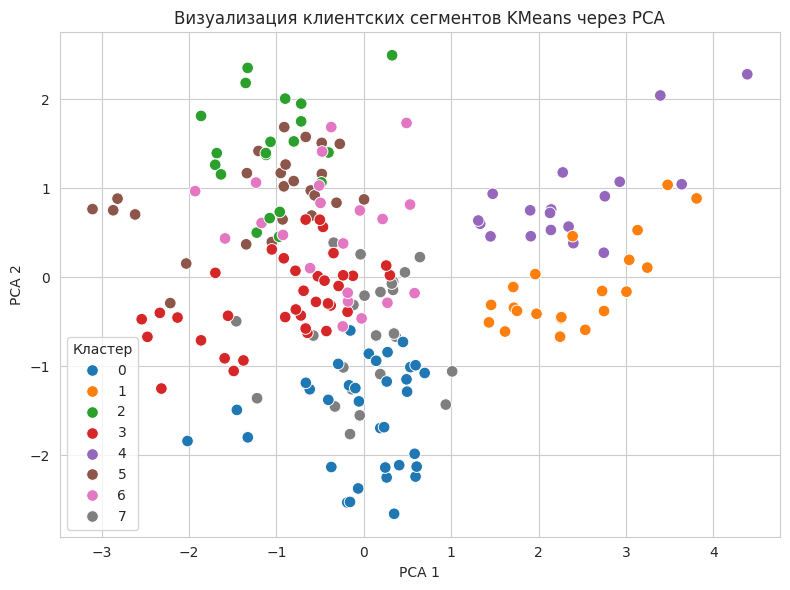

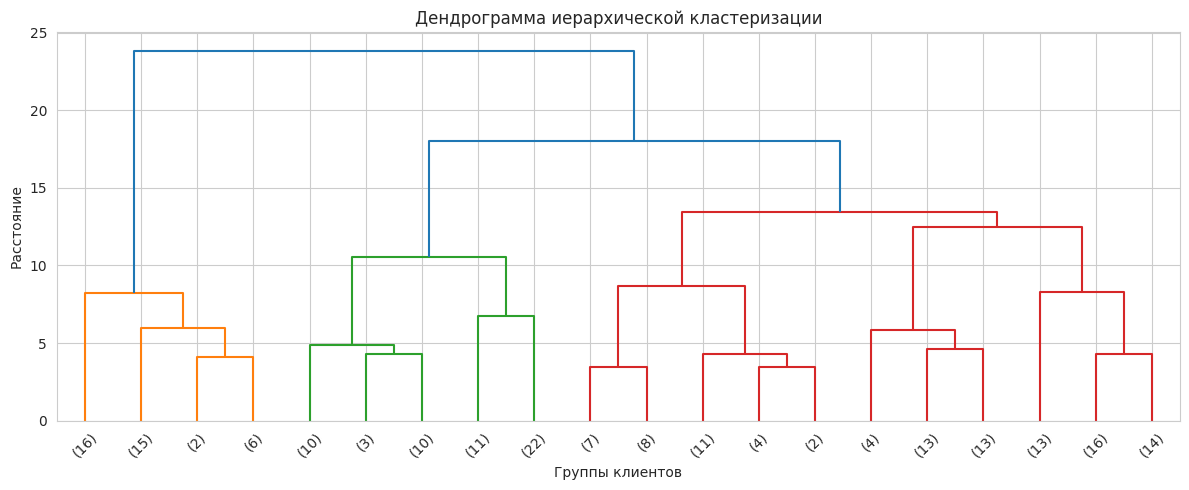

,clients,avg_age,female_share,avg_income,avg_spending,avg_purchase_potential
cluster_KMeans,,,,,,
0,34,26.00,1.0,39.53,59.50,22.19
1,21,32.19,1.0,86.05,81.67,70.48
2,20,39.50,0.0,85.15,14.05,11.99
3,36,51.28,1.0,46.72,40.72,20.64
4,18,33.28,0.0,87.11,82.67,71.64
5,26,58.00,0.0,46.73,39.92,20.63
6,21,41.00,1.0,85.86,27.00,22.63
7,24,25.25,0.0,41.25,60.92,23.98


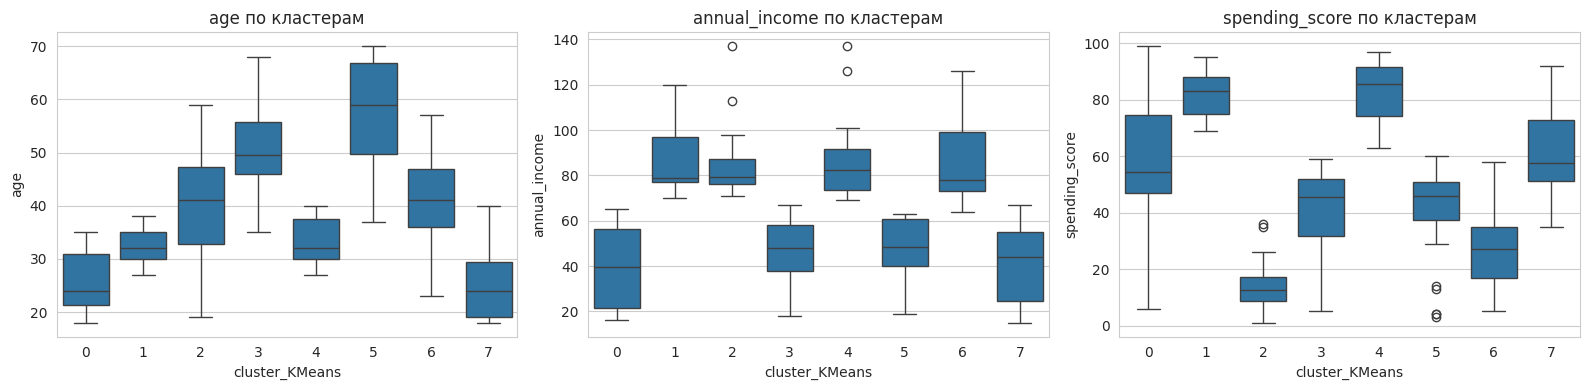

Названия сегментов:
Кластер 0: Активные клиенты с умеренным доходом
Кластер 1: Ценные активные клиенты
Кластер 2: Высокий доход, низкие траты
Кластер 3: Экономные клиенты
Кластер 4: Ценные активные клиенты
Кластер 5: Экономные клиенты
Кластер 6: Высокий доход, низкие траты
Кластер 7: Активные клиенты с умеренным доходом


,customer_id,gender,age,annual_income,spending_score,cluster_KMeans,segment_name
0,1,Male,19,15,39,7,Активные клиенты с умеренным доходом
1,2,Male,21,15,81,7,Активные клиенты с умеренным доходом
2,3,Female,20,16,6,0,Активные клиенты с умеренным доходом
3,4,Female,23,16,77,0,Активные клиенты с умеренным доходом
4,5,Female,31,17,40,0,Активные клиенты с умеренным доходом
5,6,Female,22,17,76,0,Активные клиенты с умеренным доходом
6,7,Female,35,18,6,3,Экономные клиенты
7,8,Female,23,18,94,0,Активные клиенты с умеренным доходом
8,9,Male,64,19,3,5,Экономные клиенты
9,10,Female,30,19,72,0,Активные клиенты с умеренным доходом


In [ ]:
# Шаг 5. Интерпретация и визуализация результатов
main_cluster_col = 'cluster_KMeans'

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
df_processed['pca_1'] = X_pca[:, 0]
df_processed['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_processed,
    x='pca_1',
    y='pca_2',
    hue=main_cluster_col,
    palette='tab10',
    s=70
)
plt.title('Визуализация клиентских сегментов KMeans через PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Кластер')
plt.tight_layout()
plt.show()

# Дендрограмма для иерархической кластеризации
plt.figure(figsize=(12, 5))
linked = linkage(X_scaled, method='ward')
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45, leaf_font_size=10)
plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Группы клиентов')
plt.ylabel('Расстояние')
plt.tight_layout()
plt.show()

# Профиль кластеров
cluster_profile = df_processed.groupby(main_cluster_col).agg(
    clients=('customer_id', 'count'),
    avg_age=('age', 'mean'),
    female_share=('is_female', 'mean'),
    avg_income=('annual_income', 'mean'),
    avg_spending=('spending_score', 'mean'),
    avg_purchase_potential=('avg_purchase_potential', 'mean')
).round(2)

display(cluster_profile)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['age', 'annual_income', 'spending_score']):
    sns.boxplot(data=df_processed, x=main_cluster_col, y=col, ax=ax)
    ax.set_title(f'{col} по кластерам')
plt.tight_layout()
plt.show()

# Автоматически зададим понятные бизнес-названия сегментов по средним доходу и spending score.
overall_income = df_processed['annual_income'].mean()
overall_spending = df_processed['spending_score'].mean()
segment_names = {}

for cluster_id, row in cluster_profile.iterrows():
    if row['avg_income'] >= overall_income and row['avg_spending'] >= overall_spending:
        name = 'Ценные активные клиенты'
    elif row['avg_income'] >= overall_income and row['avg_spending'] < overall_spending:
        name = 'Высокий доход, низкие траты'
    elif row['avg_income'] < overall_income and row['avg_spending'] >= overall_spending:
        name = 'Активные клиенты с умеренным доходом'
    else:
        name = 'Экономные клиенты'
    segment_names[cluster_id] = name

df_processed['segment_name'] = df_processed[main_cluster_col].map(segment_names)

print('Названия сегментов:')
for cluster_id, name in segment_names.items():
    print(f'Кластер {cluster_id}: {name}')

display(df_processed[['customer_id', 'gender', 'age', 'annual_income', 'spending_score', main_cluster_col, 'segment_name']].head(10))


#### **Шаг 6: Формирование бизнес-рекомендаций**

**6.1. Анализ потребностей каждого сегмента:**

- Определите потребности и предпочтения клиентов в каждом сегменте.
- Выявите возможности для увеличения продаж и улучшения сервиса.

**6.2. Разработка стратегий для каждого сегмента:**

- **Маркетинговые кампании:**
  - Персонализированные предложения.
  - Программы лояльности для удержания ценных клиентов.
- **Оптимизация продуктов:**
  - Расширение ассортимента для популярных сегментов.
  - Фокус на продуктах, интересных конкретным сегментам.

**6.3. Оценка потенциального влияния:**

- Оцените, как предложенные стратегии могут повысить выручку, удовлетворенность клиентов и другие ключевые показатели.

### Бизнес-рекомендации по результатам сегментации

В работе была построена сегментация клиентов торгового центра по демографическим и поведенческим признакам: возраст, пол, годовой доход, spending score и расчётный покупательский потенциал. Для кластеризации были протестированы `KMeans`, иерархическая кластеризация и `DBSCAN`. Основной алгоритм для интерпретации — `KMeans`, потому что он даёт устойчивые, непересекающиеся и легко объяснимые сегменты.

**1. Ценные активные клиенты**  
Это клиенты с доходом выше среднего и высоким spending score. Их стоит удерживать через VIP-программы, персональные скидки, ранний доступ к новым коллекциям, премиальные предложения и накопительные бонусы. Цель — сохранить лояльность и увеличить частоту покупок.

**2. Высокий доход, низкие траты**  
У этих клиентов есть платёжеспособность, но они тратят мало. Для них подойдут персонализированные рекомендации, премиальные товары, точечные промокоды, консультации и кампании, объясняющие ценность продукта. Цель — повысить вовлечённость и конверсию в покупки.

**3. Активные клиенты с умеренным доходом**  
Эти клиенты активно покупают, несмотря на более умеренный доход. Для них эффективны акции, комплекты товаров, программы лояльности, кешбэк и предложения в среднем ценовом сегменте. Цель — поддерживать частоту покупок без сильного снижения маржинальности.

**4. Экономные клиенты**  
Это клиенты с низким spending score и/или более низким доходом. Для них стоит использовать массовые акции, скидки на базовые товары, сезонные распродажи и недорогие предложения. Цель — мягко повышать активность без дорогих персональных кампаний.

**Итог:** сегментация помогает не запускать одинаковые маркетинговые кампании для всех клиентов. Вместо этого бизнес может распределять бюджет точнее: удерживать ценных клиентов, развивать клиентов с высоким потенциалом и экономнее работать с низкоактивными сегментами.


#### **Шаг 7: Документирование и презентация результатов**

**7.1. Подготовка отчета:**

- **Введение:**
  - Описание цели работы и её значимости для бизнеса.
- **Методология:**
  - Подробное описание проведенных шагов.
- **Результаты:**
  - Представление метрик оценки и визуализаций.
  - Описание сегментов клиентов.
- **Обсуждение:**
  - Анализ полученных результатов.
  - Сравнение алгоритмов и обоснование выбора.
- **Рекомендации:**
  - Предложения по внедрению результатов в бизнес-процессы.
- **Заключение:**
  - Выводы о проделанной работе и её значимости.

**7.2. Презентация:**

- Подготовьте слайды для представления ключевых моментов работы.
- Используйте визуализации для иллюстрации результатов.



## **Шаг 7. Документирование и презентация результатов**

### **7.1. Подготовка отчёта**

#### **Введение**

Цель работы — разработать систему сегментации клиентов розничной компании с помощью алгоритмов кластеризации. Такая сегментация помогает бизнесу лучше понимать различия между клиентами, персонализировать маркетинговые кампании, точнее распределять рекламный бюджет и повышать удержание наиболее ценных покупателей.

В качестве данных использован открытый датасет **Mall Customers**, содержащий 200 клиентов торгового центра. В наборе есть демографические и поведенческие признаки: пол, возраст, годовой доход и spending score — оценка покупательской активности клиента.

#### **Методология**

Работа была выполнена по следующему пайплайну:

1. Загружен и изучен датасет Mall Customers.
2. Проведён первичный анализ данных: размерность, типы признаков, описательная статистика и распределения.
3. Проверены пропуски, дубликаты и возможные выбросы.
4. Созданы дополнительные признаки для сегментации: `is_female`, `monetary_value`, `frequency_score`, `avg_purchase_potential`.
5. Числовые признаки были стандартизированы с помощью `StandardScaler`, потому что алгоритмы кластеризации чувствительны к масштабу признаков.
6. Были применены три алгоритма кластеризации: `KMeans`, `AgglomerativeClustering` и `DBSCAN`.
7. Для KMeans было подобрано количество кластеров по методу локтя и коэффициенту силуэта.
8. Качество кластеризации оценивалось внутренними метриками: silhouette score, Davies-Bouldin index и Calinski-Harabasz index.
9. Для визуализации применялись PCA, scatter plot, дендрограмма и профили кластеров.

#### **Результаты**

По коэффициенту силуэта лучше всего показала себя иерархическая кластеризация:

| Алгоритм | Кол-во кластеров | Silhouette | Davies-Bouldin | Calinski-Harabasz |
|---|---:|---:|---:|---:|
| Agglomerative | 8 | 0.3706 | 0.9209 | 79.1999 |
| KMeans | 8 | 0.3705 | 1.0284 | 84.8376 |
| DBSCAN | 3 + шум | 0.2359 | 1.3368 | 43.3122 |

Хотя `AgglomerativeClustering` немного лучше по silhouette score, для итоговой интерпретации выбран `KMeans`, потому что он даёт устойчивые, простые и легко объяснимые бизнес-сегменты.

KMeans разделил клиентов на 8 кластеров, которые можно объединить в 4 смысловые группы:

| Сегмент | Смысл |
|---|---|
| Ценные активные клиенты | Высокий доход и высокий spending score |
| Высокий доход, низкие траты | Клиенты с платёжеспособностью, но низкой активностью |
| Активные клиенты с умеренным доходом | Часто покупают, несмотря на более умеренный доход |
| Экономные клиенты | Низкий spending score и/или умеренный доход |

#### **Обсуждение**

Результаты показывают, что клиенты торгового центра неоднородны. Одинаковая маркетинговая стратегия для всех клиентов будет неэффективной: часть клиентов уже активно покупает, часть имеет высокий потенциал, но пока тратит мало, а часть чувствительна к цене.

`DBSCAN` оказался менее подходящим для этой задачи: он выделил шумовые объекты и показал более слабые значения внутренних метрик. `AgglomerativeClustering` хорошо подходит для анализа структуры данных и дендрограммы, но `KMeans` удобнее для практического внедрения, потому что каждому клиенту можно быстро назначить понятный номер сегмента.

#### **Рекомендации**

1. **Ценные активные клиенты:** использовать VIP-программы, персональные предложения, ранний доступ к акциям и премиальные рекомендации.
2. **Высокий доход, низкие траты:** запускать кампании с персональными рекомендациями, премиальными товарами и акцентом на ценность продукта.
3. **Активные клиенты с умеренным доходом:** предлагать акции, кешбэк, комплекты товаров и программы лояльности среднего ценового сегмента.
4. **Экономные клиенты:** использовать массовые скидки, сезонные распродажи и недорогие предложения без больших затрат на персональный маркетинг.

#### **Заключение**

В ходе работы была построена система сегментации клиентов на основе алгоритмов кластеризации. Были сравнены KMeans, иерархическая кластеризация и DBSCAN, рассчитаны метрики качества и сформированы бизнес-интерпретируемые сегменты. Полученные результаты можно использовать для персонализации маркетинга, удержания ценных клиентов и более точного распределения рекламного бюджета.

### **7.2. Презентация**

Для представления результатов подготовлена отдельная презентация PowerPoint. В неё вынесены цель работы, методология, сравнение алгоритмов, описание клиентских сегментов и бизнес-рекомендации.
